# 05 — Telco: Boosting, comparison and model choice

**Objective:** Add boosting models to the same experiment, compare all candidates, and make a model choice using both technical evidence and business criteria.

## Rebuild the Session 2 experiment

We repeat the setup so this notebook can run on its own. Parsing `TotalCharges` learns nothing from other customers. Imputation, scaling and encoding must be learned inside each training fold, as in notebook 03. Observe that the dataset and column groups stay unchanged.

In [1]:
# Use Path so the repository-relative data location works across operating systems.
from pathlib import Path

# Import pandas to load the CSV, parse values, and display result tables.
import pandas as pd
# Route named column groups through different preprocessing branches.
from sklearn.compose import ColumnTransformer
# Learn a replacement value for missing numeric observations.
from sklearn.impute import SimpleImputer
# Use the linear classifier taught in Session 2.
from sklearn.linear_model import LogisticRegression
# Import the holdout split, stratified folds, and cross-validation runner.
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
# Chain learned transformations and the classifier inside one training boundary.
from sklearn.pipeline import Pipeline
# Scale numeric columns and encode categorical columns without ordinal assumptions.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Point from the notebooks folder to the course CSV stored in the repository.
data_path = Path("../data/telco.csv")
# Load one row per customer into a DataFrame.
df = pd.read_csv(data_path)

# Parse each value independently; this deterministic step learns no population statistic.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],  # Start from the original text column.
    errors="coerce"  # Convert whitespace-only values to NaN, never to zero.
)

## Define predictors and target

`Churn` is the outcome we want to predict, so it cannot also be an input. `customerID` identifies a customer but is not evidence that the customer will churn.

In [2]:
# Remove the outcome and identifier so neither can become a model input.
X = df.drop(columns=["Churn", "customerID"])
# Encode observed churn as 1 and non-churn as 0 for binary classification.
y = df["Churn"].eq("Yes").astype(int)

# Confirm the number of customer rows and usable predictor columns.
print(f"Predictor shape: {X.shape}")
# Report target prevalence because it motivates stratification and Average Precision.
print(f"Churn rate: {y.mean():.1%}")

Predictor shape: (7043, 19)
Churn rate: 26.5%


## Route numeric and categorical columns

For this course example, `tenure`, `MonthlyCharges`, and `TotalCharges` are numeric. Every other predictor is treated as categorical. In particular, `SeniorCitizen` is stored as 0/1 but represents a category rather than a measured quantity.

In [3]:
# List the measured quantities that need numeric imputation and scaling.
numeric_columns = [
    "tenure",  # Duration measured in months.
    "MonthlyCharges",  # Current monthly amount charged.
    "TotalCharges"  # Accumulated amount, including the parsed missing values.
]

# Route every remaining predictor, including SeniorCitizen, as a category.
categorical_columns = [
    column for column in X.columns  # Inspect every available predictor name.
    if column not in numeric_columns  # Exclude the three numeric columns listed above.
]

# Make the manual routing visible before any preprocessing is fitted.
print("Numeric:", numeric_columns)
# Confirm which fields will be converted to one-hot indicator columns.
print("Categorical:", categorical_columns)

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Define preprocessing

The numeric branch follows this sequence:

`missing value → median imputation → standard scaling`

The median, mean, and standard deviation are learned from training rows. Validation rows may be transformed with those learned values but must never change them.

The categorical branch uses one-hot encoding. Categories become indicator columns without introducing an artificial numeric order. `handle_unknown="ignore"` lets the encoder process a category not seen during a particular training fold without refitting on validation data.

In [4]:
# Define an unfitted numeric sequence; its statistics will be learned inside each fold.
numeric_preprocessing = Pipeline([
    ("impute", SimpleImputer(strategy="median")),  # Learn training medians for NaN values.
    ("scale", StandardScaler())  # Learn training means and standard deviations.
])

# Send each named column group through its own transformation branch.
preprocess = ColumnTransformer([
    ("num", numeric_preprocessing, numeric_columns),  # Impute and scale numeric fields.
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),  # Encode categories and tolerate unseen ones.
        categorical_columns  # Apply the encoder only to the categorical fields.
    )
], remainder="drop")  # Drop any predictor not explicitly assigned to a branch.

## Lock the final test set

We reserve 20% of the rows before cross-validation. The locked set does not participate in validation, model selection, or preprocessing decisions, and it is not scored in this notebook.

In [5]:
# Reserve the final test boundary before cross-validation or learned preprocessing.
X_dev, X_locked, y_dev, y_locked = train_test_split(
    X,  # Split the raw predictor rows before fitting any transformer.
    y,  # Apply the identical row split to the target.
    test_size=0.20,  # Lock 20% away for a future final evaluation.
    stratify=y,  # Preserve approximately the same churn share in both subsets.
    random_state=42  # Make the holdout membership reproducible.
)

# Report only subset sizes; do not inspect or score the locked labels.
split_summary = pd.Series({
    "Development rows": len(X_dev),  # These rows may enter cross-validation.
    "Locked test rows": len(X_locked),  # These rows remain untouched here.
})
# Display the boundary so students can verify the 80/20 split.
split_summary

Development rows    5634
Locked test rows    1409
dtype: int64

## Five-fold stratified cross-validation

A fold is one partition of the development data. Five folds create five rounds: each development row is used for validation once and for training in the other four rounds. The five fitted Pipelines are temporary; the result we inspect is the five validation scores. Stratification keeps approximately the same churn proportion in every validation fold.

In [6]:
# Define the five reproducible train/validation partitions of development data.
cv = StratifiedKFold(
    n_splits=5,  # Create five rounds, with each row validating exactly once.
    shuffle=True,  # Randomize row order before assigning folds.
    random_state=42  # Reproduce the same shuffled fold membership.
)

In [7]:
# Save the exact five partitions once, then reuse them for every model.
folds = list(cv.split(X_dev, y_dev))

**The locked test will not be used to choose between models.** All scores below use Development rows only.

Same data → Same preprocessing → Same folds → Same metric → Different model.

Change one thing. Observe what happens.

In [8]:
# Draw a simple coefficient summary.
import matplotlib.pyplot as plt
# Rebuild the forest from notebook 04.
from sklearn.ensemble import RandomForestClassifier
# Collect validation scores together with fitting times.
from sklearn.model_selection import cross_validate
# Rebuild the unrestricted tree from notebook 04.
from sklearn.tree import DecisionTreeClassifier
# Add the first boosting implementation.
from xgboost import XGBClassifier
# Add the second boosting implementation.
from lightgbm import LGBMClassifier

## Logistic Regression reference

Start with the same Session 2 Pipeline and AP scores. This reference tells us whether the more complex candidates add value.

In [9]:
# Keep the same preprocessing and replace only the classifier.
logistic_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", LogisticRegression(C=1, solver="lbfgs", max_iter=2000)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
logistic_scores = cross_val_score(logistic_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(logistic_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {logistic_scores.mean():.3f}; Fold std: {logistic_scores.std(ddof=1):.3f}")

1    0.643523
2    0.635589
3    0.685717
4    0.678189
5    0.664162
Name: Fold AP, dtype: float64
Mean AP: 0.661; Fold std: 0.022


## XGBoost

Tree 1 makes a first approximation. Tree 2 tries to correct what the current model still gets wrong. The final model combines all the accumulated trees.

The second tree does not replace the first. All observations remain in the process; each new tree adds a correction. We use 100 small trees with fixed settings, without tuning. Observe their AP against the reference.

In [10]:
# Keep the same preprocessing and replace only the classifier.
xgboost_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=1)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
xgboost_scores = cross_val_score(xgboost_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(xgboost_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {xgboost_scores.mean():.3f}; Fold std: {xgboost_scores.std(ddof=1):.3f}")

1    0.651280
2    0.631655
3    0.691968
4    0.689122
5    0.681355
Name: Fold AP, dtype: float64
Mean AP: 0.669; Fold std: 0.026


## LightGBM

Same boosting idea: trees are still added sequentially. LightGBM is designed to grow trees efficiently, focusing growth where it expects the largest improvement.

Again, these are fixed classroom settings, not optimized settings. Compare its validation scores with XGBoost under the same experiment.

In [11]:
# Keep the same preprocessing and replace only the classifier.
lightgbm_model = Pipeline([
    ("preprocess", preprocess),  # Learn transformations inside each training fold.
    ("classifier", LGBMClassifier(n_estimators=100, num_leaves=15, learning_rate=0.1, random_state=42, n_jobs=1, verbosity=-1)),  # Use this fixed classroom configuration.
])
# Compute Average Precision on the same five Development validation folds.
lightgbm_scores = cross_val_score(lightgbm_model, X_dev, y_dev, cv=folds, scoring="average_precision")
# Display every fold so the mean does not hide variation.
print(pd.Series(lightgbm_scores, index=range(1, 6), name="Fold AP"))
# Summarize validation performance and sample fold variation.
print(f"Mean AP: {lightgbm_scores.mean():.3f}; Fold std: {lightgbm_scores.std(ddof=1):.3f}")

1    0.650423
2    0.612195
3    0.685485
4    0.664474
5    0.671075
Name: Fold AP, dtype: float64
Mean AP: 0.657; Fold std: 0.028


## Compare all five models

A small dictionary makes the experiment visible: only the estimator changes in the loop. Decision Tree means the unrestricted tree from notebook 04.

`cross_validate` resembles `cross_val_score`, but returns additional information such as fitting time. Its `test_score` means the validation fold, **not the Locked Test**. We rerun all candidates here to collect scores and times together. Fitting is sequential, with one worker per forest or boosting model.

In [12]:
# List fixed candidate estimators; preprocessing and folds remain outside this choice.
models = {
    "Logistic Regression": LogisticRegression(C=1, solver="lbfgs", max_iter=2000),  # Reuse the Session 2 reference.
    "Decision Tree": DecisionTreeClassifier(random_state=42),  # Use the full tree.
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),  # Combine 100 trees.
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=1),  # Accumulate 100 small correction trees.
    "LightGBM": LGBMClassifier(n_estimators=100, num_leaves=15, learning_rate=0.1, random_state=42, n_jobs=1, verbosity=-1),  # Accumulate 100 efficiently grown trees.
}
# Collect one result row per candidate.
rows = []
# Change only the estimator while repeating the same experiment.
for name, estimator in models.items():
    # Keep all learned transformations within the training boundary.
    model = Pipeline([("preprocess", preprocess), ("classifier", estimator)])
    # Fit five independent copies and measure validation AP plus fitting duration.
    result = cross_validate(model, X_dev, y_dev, cv=folds, scoring="average_precision")
    # Retrieve the five validation scores, not any Locked Test scores.
    scores = result["test_score"]
    # Label each score by its shared validation fold.
    row = {f"Fold {i}": score for i, score in enumerate(scores, start=1)}
    # Add the model name and transparent summary measurements.
    row.update({"Model": name, "Mean AP": scores.mean(), "Fold std": scores.std(ddof=1),
                "Mean fit time": result["fit_time"].mean()})
    # Keep this candidate's measurements for the final table.
    rows.append(row)
# Preserve model order and full precision for later decisions.
comparison = pd.DataFrame(rows).set_index("Model")
# Display all fold scores and fitting times in seconds.
comparison.round(3)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean AP,Fold std,Mean fit time
Model,,,,,,,,
Logistic Regression,0.644,0.636,0.686,0.678,0.664,0.661,0.022,0.075
Decision Tree,0.373,0.371,0.387,0.382,0.377,0.378,0.007,0.075
Random Forest,0.562,0.596,0.634,0.612,0.641,0.609,0.032,0.724
XGBoost,0.651,0.632,0.692,0.689,0.681,0.669,0.026,0.253
LightGBM,0.650,0.612,0.685,0.664,0.671,0.657,0.028,0.151


Mean AP measures predictive performance. Fold std describes variation across these folds, giving one indication of stability; it is not a guarantee of future stability. A consistently weak model can have a small fold std: stability alone does not make a model useful. Mean fit time measures computational cost **in this environment and on this dataset**, including preprocessing. It is not a universal property of an algorithm.

## Which variables influence Logistic Regression most?

Fit the reference on Development only, then inspect its actual coefficients. Numeric coefficients refer to scaled variables. For each categorical field, sum the absolute coefficients of its one-hot categories to describe the whole concept.

This is a simple descriptive coefficient summary, not a causal effect or a share of predictive performance. A field with more categories can receive a larger sum; correlated fields can share weight. We use magnitude, not sign, and normalize only the five largest concepts to 100%.

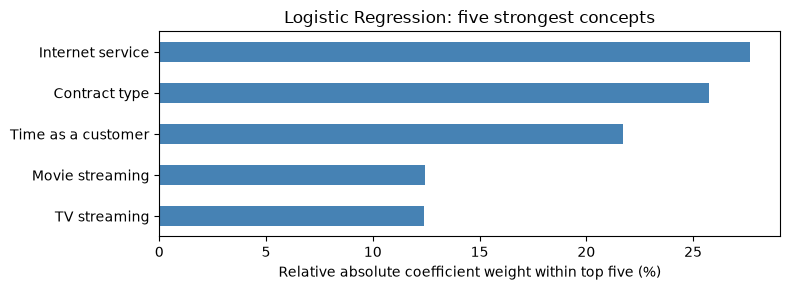

In [13]:
# Fit the reference on Development only to obtain actual learned coefficients.
logistic_model.fit(X_dev, y_dev);
# Start the original-field mapping with the three numeric outputs in their order.
original_fields = list(numeric_columns)
# Retrieve the fitted encoder so category counts match this fitted model.
encoder = logistic_model.named_steps["preprocess"].named_transformers_["cat"]
# Map each one-hot output back to its original categorical field.
for column, categories in zip(categorical_columns, encoder.categories_):
    # Repeat the original name once for each encoded category, in encoder order.
    original_fields.extend([column] * len(categories))
# Pair each fitted coefficient magnitude with its original field.
magnitudes = pd.Series(abs(logistic_model.named_steps["classifier"].coef_[0]), index=original_fields)
# Sum category magnitudes within each concept and keep the largest five.
top_five = magnitudes.groupby(level=0).sum().nlargest(5)
# Express relative weight within these five concepts as percentages totaling 100.
relative_weight = 100 * top_five / top_five.sum()
# Translate dataset fields into plain customer concepts.
human_names = {"tenure": "Time as a customer", "MonthlyCharges": "Monthly charges",
               "TotalCharges": "Total charges", "Contract": "Contract type",
               "PaymentMethod": "Payment method", "InternetService": "Internet service",
               "OnlineSecurity": "Online security", "OnlineBackup": "Online backup",
               "DeviceProtection": "Device protection", "TechSupport": "Technical support",
               "StreamingTV": "TV streaming", "StreamingMovies": "Movie streaming",
               "PaperlessBilling": "Paperless billing", "SeniorCitizen": "Senior customer",
               "gender": "Gender", "Partner": "Partner", "Dependents": "Dependents",
               "PhoneService": "Phone service", "MultipleLines": "Multiple phone lines"}
# Rename concepts and order the bars so the strongest appears at the top.
plot_weights = relative_weight.rename(index=human_names).sort_values()
# Draw a short horizontal chart with readable concept labels.
plot_weights.plot.barh(figsize=(8, 3), color="steelblue")
# Explain exactly what the percentages represent.
plt.xlabel("Relative absolute coefficient weight within top five (%)")
# Identify the fitted model being described.
plt.title("Logistic Regression: five strongest concepts")
# Keep all labels inside the figure.
plt.tight_layout()
# Display the chart without extra plotting-object output.
plt.show()

## Model choice: evidence is not the same as decision

The weights are visible before scoring:

| Criterion | Weight | Source |
|---|---:|---|
| Performance | 40% | Measured mean AP |
| Stability | 20% | Measured fold std |
| Interpretability | 10% | Human judgement |
| Cost / speed | 10% | Measured mean fit time |
| Business fit | 20% | Human judgement |

Scale: **0 = weak, 1 = acceptable, 2 = strong**.

For this classroom example, choose rules before looking for a winner: performance is strong within 0.02 AP of the best, acceptable within 0.10, and weak beyond that substantial gap. Stability is strong within 0.01 of the smallest fold std, otherwise acceptable; we do not assign zero based only on five folds. Speed is strong within twice the fastest mean fit time, otherwise acceptable; these small runtimes alone do not justify zero. The cutoffs are explicit classroom judgement, not universal standards.

Assume a retention team needs a customer ranking and a model it can explain. Interpretability: Logistic Regression = 2 because coefficients offer a compact summary; the unrestricted tree = 1 because a large tree is difficult to read; forest and boosting = 1 because their many trees are harder to summarize. Business fit: all five = 1 because they provide rankings, but we have no operational evidence to claim strong fit or reject any candidate. A different use case can change these judgements.

Measured evidence informs the first three ratings; interpretability and business fit are explicitly human ratings.

In [14]:
# State business priorities as fractions that sum to one.
weights = pd.Series({"Performance": 0.40, "Stability": 0.20, "Interpretability": 0.10,
                     "Cost / speed": 0.10, "Business fit": 0.20})
# Keep the decision matrix aligned with the measured comparison table.
ratings = pd.DataFrame(index=comparison.index)
# Measure each candidate's AP gap behind the best observed mean.
ap_gap = comparison["Mean AP"].max() - comparison["Mean AP"]
# Start with acceptable performance for all candidates.
ratings["Performance"] = 1
# Award strong performance only within the declared 0.02 AP gap.
ratings.loc[ap_gap <= 0.02, "Performance"] = 2
# Assign weak performance only for the declared substantial AP gap.
ratings.loc[ap_gap > 0.10, "Performance"] = 0
# Start with acceptable stability because five folds provide limited evidence.
ratings["Stability"] = 1
# Award strong stability within 0.01 of the smallest observed fold variation.
ratings.loc[comparison["Fold std"] <= comparison["Fold std"].min() + 0.01, "Stability"] = 2
# State the interpretability judgement in the same order as the model table.
ratings["Interpretability"] = [2, 1, 1, 1, 1]
# Start with acceptable computational cost for this small dataset.
ratings["Cost / speed"] = 1
# Award strong speed to candidates within twice the fastest measured fit time.
ratings.loc[comparison["Mean fit time"] <= 2 * comparison["Mean fit time"].min(), "Cost / speed"] = 2
# Keep business fit acceptable pending operational evidence for each candidate.
ratings["Business fit"] = 1
# Multiply each criterion score by its visible weight and sum across the row.
weighted_score = (ratings * weights).sum(axis=1)
# Show the ratings and their weighted totals together.
ratings["Weighted score"] = weighted_score
# Display the matrix without hiding individual criterion ratings.
ratings.round(2)

,Performance,Stability,Interpretability,Cost / speed,Business fit,Weighted score
Model,,,,,,
Logistic Regression,2,1,2,2,1,1.6
Decision Tree,0,2,1,2,1,0.9
Random Forest,1,1,1,1,1,1.0
XGBoost,2,1,1,1,1,1.4
LightGBM,2,1,1,1,1,1.4


In [15]:
# Preserve ties instead of forcing a unique winner.
preferred = weighted_score[weighted_score == weighted_score.max()].index.tolist()
# Report the candidates preferred under this explicit classroom scenario.
print("Preferred candidate(s) under these priorities:", ", ".join(preferred))

Preferred candidate(s) under these priorities: Logistic Regression


Read the matrix alongside the measured table. Explain any zero using the stated AP gap. Are the interpretability and business-fit judgements reasonable for the assumed team?

**The experiment produces evidence. People still have to make the decision.**

**The weights reflect this use case. Change the business priorities, and the preferred model may change.** This illustrates a Development/CV candidate choice, not a final deployment decision. The Locked Test remains untouched for the appropriate later stage.

Implementation references: [XGBoost classifier API](https://xgboost.readthedocs.io/en/stable/python/python_api.html) and [LightGBM parameters](https://lightgbm.readthedocs.io/en/latest/Parameters.html).